In [33]:
from potentials import CellInteractionSimulation
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from ipywidgets import interactive, FloatSlider

In [34]:
simulation = CellInteractionSimulation()

In [35]:
# Use the setter methods to set the parameters
simulation.r_default = 5
simulation.r1 = simulation.r_default
simulation.r2 = simulation.r_default
simulation.c1_repulsion = 10.0
simulation.c2_repulsion = 10.0
simulation.c1_adhesion = 0.4
simulation.c2_adhesion = 0.4
simulation.c1_relative_maximum_adhesion_distance = simulation.r1 * 1.25
simulation.c2_relative_maximum_adhesion_distance = simulation.r1 * 1.25

# Use the getter methods to retrieve the parameters
print("r_default:", simulation.r_default)
print("r1:", simulation.r1)
print("r2:", simulation.r2)
print("c1_repulsion:", simulation.c1_repulsion)
print("c2_repulsion:", simulation.c2_repulsion)
print("c1_adhesion:", simulation.c1_adhesion)
print("c2_adhesion:", simulation.c2_adhesion)
print("c1_relative_maximum_adhesion_distance:", simulation.c1_relative_maximum_adhesion_distance)
print("c2_relative_maximum_adhesion_distance:", simulation.c2_relative_maximum_adhesion_distance)

r_default: 5
r1: 5
r2: 5
c1_repulsion: 10.0
c2_repulsion: 10.0
c1_adhesion: 0.4
c2_adhesion: 0.4
c1_relative_maximum_adhesion_distance: 6.25
c2_relative_maximum_adhesion_distance: 6.25


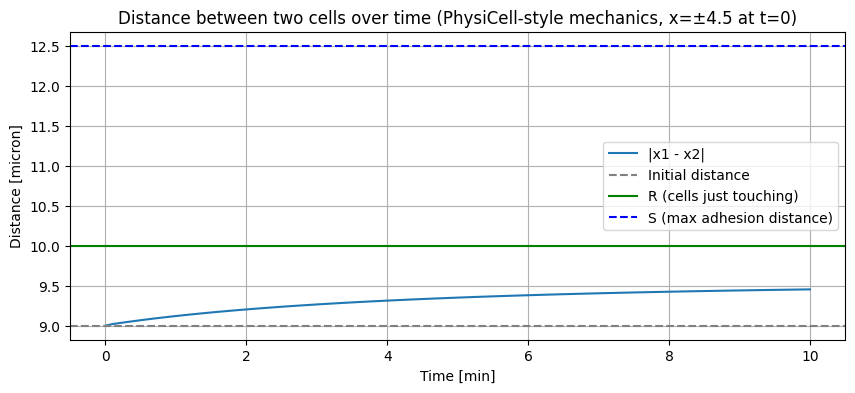

In [36]:
# Two-cell interaction (PhysiCell-style mechanics) starting at x=+4.5 and x=-4.5
#
#!/!\ NOTE
# This implements the same *interaction velocity* formula used in PhysiCell's `Cell::add_potentials`
# (repulsion + adhesion, with (1-d/R)^2 and (1-d/S)^2 terms, divided by distance),
# and the same Adams–Bashforth position update used in `Cell::update_position`.

# Make the cell runnable even in a fresh kernel (best effort).
try:
    simulation  # noqa: F821
except NameError:
    from potentials import CellInteractionSimulation
    import numpy as np
    import matplotlib.pyplot as plt
    simulation = CellInteractionSimulation()

# Ensure numpy/matplotlib are available even if the notebook was run out of order
try:
    np  # noqa: F821
except NameError:
    import numpy as np
try:
    plt  # noqa: F821
except NameError:
    import matplotlib.pyplot as plt

# Parameters matching PhysiCell_settings.xml (cell_definition "agent")
simulation.r_default = 5.0
simulation.r1 = simulation.r_default
simulation.r2 = simulation.r_default
simulation.c1_repulsion = 10.0
simulation.c2_repulsion = 10.0
simulation.c1_adhesion = 0.4
simulation.c2_adhesion = 0.4
simulation.c1_relative_maximum_adhesion_distance = 1.25
simulation.c2_relative_maximum_adhesion_distance = 1.25

# Derived quantities (match PhysiCell logic)
simulation.R = simulation.r1 + simulation.r2
simulation.S = (simulation.c1_relative_maximum_adhesion_distance * simulation.r1) + (simulation.c2_relative_maximum_adhesion_distance * simulation.r2)
simulation.effective_repulsion = np.sqrt(simulation.c1_repulsion * simulation.c2_repulsion)
simulation.effective_adhesion = np.sqrt(simulation.c1_adhesion * simulation.c2_adhesion)

# Initial positions (1D along x)
x1_0 = 4.5
x2_0 = -4.5

# PhysiCell settings (see PhysiCell_settings.xml)
dt = 0.1   # dt_mechanics [min]
T = 10.0   # max_time [min]
N = int(T / dt)
time = np.linspace(0.0, T, N + 1)

# Adams–Bashforth coefficients (same as PhysiCell `update_position`)
d1 = 1.5 * dt
d2 = -0.5 * dt

# State arrays
x1 = np.zeros(N + 1)
x2 = np.zeros(N + 1)
v1 = np.zeros(N + 1)
v2 = np.zeros(N + 1)
prev_v1 = np.zeros(N + 1)
prev_v2 = np.zeros(N + 1)
distances = np.zeros(N + 1)

x1[0] = x1_0
x2[0] = x2_0
prev_v1[0] = 0.0
prev_v2[0] = 0.0

R = simulation.R
S = simulation.S
effective_repulsion = simulation.effective_repulsion
effective_adhesion = simulation.effective_adhesion

eps = 1e-5  # PhysiCell uses max(distance, 1e-5) to avoid divide-by-zero

for n in range(N):
    # Displacement from cell2 to cell1 (1D)
    displacement = x1[n] - x2[n]
    distance = max(abs(displacement), eps)
    distances[n] = distance

    # --- Match PhysiCell::add_potentials ---
    # Repulsion term
    if distance > R:
        temp_r = 0.0
    else:
        temp_r = (1.0 - distance / R) ** 2
        temp_r *= effective_repulsion

    # Adhesion term (only within max interactive distance S)
    if distance < S:
        temp_a = (1.0 - distance / S) ** 2
        temp_a *= effective_adhesion
        temp_r -= temp_a

    # Convert scalar interaction to velocity along the line of centers
    if abs(temp_r) < 1e-16:
        v1[n] = 0.0
        v2[n] = 0.0
    else:
        temp_r_over_d = temp_r / distance
        v1[n] = displacement * temp_r_over_d
        v2[n] = (-displacement) * temp_r_over_d

    # --- Match PhysiCell::update_position (Adams–Bashforth) ---
    x1[n + 1] = x1[n] + d1 * v1[n] + d2 * prev_v1[n]
    x2[n + 1] = x2[n] + d1 * v2[n] + d2 * prev_v2[n]

    # Store previous velocity for next step
    prev_v1[n + 1] = v1[n]
    prev_v2[n + 1] = v2[n]

# Final distance
distances[N] = max(abs(x1[N] - x2[N]), eps)

plt.figure(figsize=(10, 4))
plt.plot(time, distances, label="|x1 - x2|")
plt.axhline(y=abs(x1_0 - x2_0), color="gray", linestyle="--", label="Initial distance")
plt.axhline(y=R, color="green", linestyle="-", label="R (cells just touching)")
plt.axhline(y=S, color="blue", linestyle="--", label="S (max adhesion distance)")
plt.xlabel("Time [min]")
plt.ylabel("Distance [micron]")
plt.title("Distance between two cells over time (PhysiCell-style mechanics, x=±4.5 at t=0)")
plt.grid(True)
plt.legend()
plt.show()

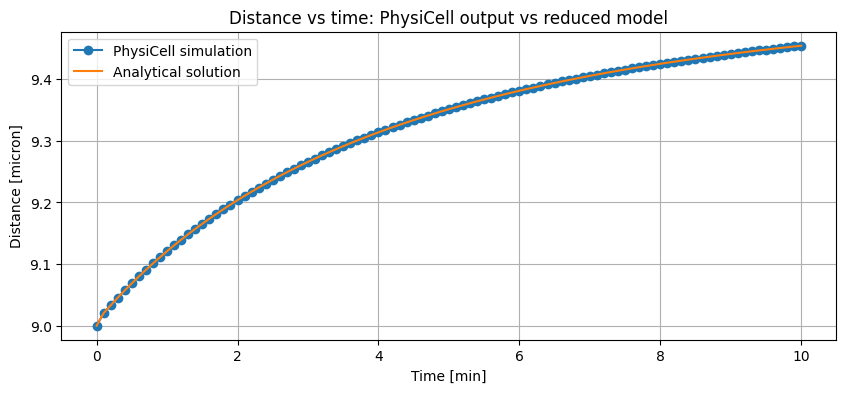

In [37]:
# Compare analytical (pairwise) vs PhysiCell simulation output using pctk
import os
import glob
import xml.etree.ElementTree as ET
import pandas as pd
import pctk
from pctk.multicellds import MultiCellDS

results_dir = "/home/tntiniak/Work/observatory_benchmark/PhysiCell/results/mechanics_pushing"

# --- Load PhysiCell simulation output time series (2 cells) ---
mcds = MultiCellDS(output_folder=results_dir, xml_fname="output00000000.xml")

xml_files = sorted(glob.glob(os.path.join(results_dir, "output*.xml")))
if len(xml_files) == 0:
    raise FileNotFoundError(f"No output*.xml found in {results_dir}")

sim_time = []
sim_distance = []

for xml_path in xml_files:
    tree = ET.parse(xml_path)
    root = tree.getroot()
    t = float(root.find("metadata").find("current_time").text)
    cell_matrix = mcds.get_cells_matrix(tree)
    df = pd.DataFrame(cell_matrix, columns=mcds.cell_columns).set_index("ID")

    # Expect exactly two cells with IDs 0 and 1 (from results_dir/cells.csv)
    p0 = df.loc[0.0, ["x_position", "y_position", "z_position"]].to_numpy(dtype=float)
    p1 = df.loc[1.0, ["x_position", "y_position", "z_position"]].to_numpy(dtype=float)
    d = float(np.linalg.norm(p0 - p1))

    sim_time.append(t)
    sim_distance.append(d)

sim_time = np.asarray(sim_time, dtype=float)
sim_distance = np.asarray(sim_distance, dtype=float)

# --- Analytical / reduced model (same code as previous cell) ---
simulation.r_default = 5.0
simulation.r1 = simulation.r_default
simulation.r2 = simulation.r_default
simulation.c1_repulsion = 10.0
simulation.c2_repulsion = 10.0
simulation.c1_adhesion = 0.4
simulation.c2_adhesion = 0.4
simulation.c1_relative_maximum_adhesion_distance = 1.25
simulation.c2_relative_maximum_adhesion_distance = 1.25
simulation.R = simulation.r1 + simulation.r2
simulation.S = (simulation.c1_relative_maximum_adhesion_distance * simulation.r1) + (simulation.c2_relative_maximum_adhesion_distance * simulation.r2)
simulation.effective_repulsion = np.sqrt(simulation.c1_repulsion * simulation.c2_repulsion)
simulation.effective_adhesion = np.sqrt(simulation.c1_adhesion * simulation.c2_adhesion)

x1_0 = 4.5
x2_0 = -4.5
dt = 0.1
T = 10.0
N = int(T / dt)
ana_time = np.linspace(0.0, T, N + 1)

d1 = 1.5 * dt
d2 = -0.5 * dt

x1 = np.zeros(N + 1)
x2 = np.zeros(N + 1)
v1 = np.zeros(N + 1)
v2 = np.zeros(N + 1)
prev_v1 = np.zeros(N + 1)
prev_v2 = np.zeros(N + 1)
ana_distance = np.zeros(N + 1)

x1[0] = x1_0
x2[0] = x2_0
prev_v1[0] = 0.0
prev_v2[0] = 0.0

R = simulation.R
S = simulation.S
effective_repulsion = simulation.effective_repulsion
effective_adhesion = simulation.effective_adhesion
eps = 1e-5

for n in range(N):
    displacement = x1[n] - x2[n]
    distance = max(abs(displacement), eps)
    ana_distance[n] = distance

    if distance > R:
        temp_r = 0.0
    else:
        temp_r = (1.0 - distance / R) ** 2
        temp_r *= effective_repulsion

    if distance < S:
        temp_a = (1.0 - distance / S) ** 2
        temp_a *= effective_adhesion
        temp_r -= temp_a

    if abs(temp_r) < 1e-16:
        v1[n] = 0.0
        v2[n] = 0.0
    else:
        temp_r_over_d = temp_r / distance
        v1[n] = displacement * temp_r_over_d
        v2[n] = (-displacement) * temp_r_over_d

    x1[n + 1] = x1[n] + d1 * v1[n] + d2 * prev_v1[n]
    x2[n + 1] = x2[n] + d1 * v2[n] + d2 * prev_v2[n]
    prev_v1[n + 1] = v1[n]
    prev_v2[n + 1] = v2[n]

ana_distance[N] = max(abs(x1[N] - x2[N]), eps)

# --- Plot comparison ---
plt.figure(figsize=(10, 4))
plt.plot(sim_time, sim_distance, "o-", label="PhysiCell simulation")
plt.plot(ana_time, ana_distance, "-", label="Analytical solution")
# plt.axhline(y=abs(x1_0 - x2_0), color="gray", linestyle="--", label="Initial distance")
# plt.axhline(y=R, color="green", linestyle="-", label="R (cells just touching)")
# plt.axhline(y=S, color="blue", linestyle="--", label="S (max adhesion distance)")
plt.xlabel("Time [min]")
plt.ylabel("Distance [micron]")
plt.title("Distance vs time: PhysiCell output vs reduced model")
plt.grid(True)
plt.legend()
plt.show()

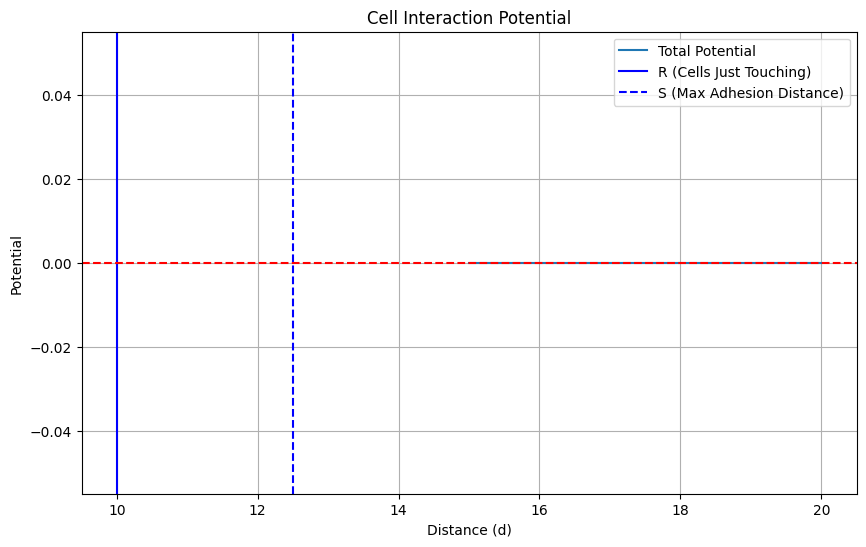

In [38]:
# Distance array
d = np.linspace(15, 20, 10)

total_potential = []
adhesion_potential = []
repulsion_potential = []
for elem in d:
    potential, repulsion, adhesion = simulation.cell_interaction_potential(elem)
    total_potential.append(potential)
    adhesion_potential.append(adhesion)
    repulsion_potential.append(repulsion)

# Now plot:
plt.figure(figsize=(10, 6))
plt.plot(d, total_potential, label='Total Potential')

# Uncomment these lines if you'd like to also plot the components
# plt.plot(d, repulsion_potential, label='Repulsive Potential')
# plt.plot(d, adhesion_potential, label='Adhesive Potential')

plt.axvline(x=simulation.R, color='blue', linestyle='-', label='R (Cells Just Touching)')
plt.axvline(x=simulation.S, color='blue', linestyle='--', label='S (Max Adhesion Distance)')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Distance (d)')
plt.ylabel('Potential')
plt.title('Cell Interaction Potential')
plt.legend()
plt.grid(True)
plt.show()

In [39]:

time_step_slider = FloatSlider(value=0.01, min=0.001, max=0.1, step=0.001,
                                       description='Time Step (dt):', readout_format='.4f')
initial_velocity_slider = FloatSlider(value=0.0, min=-5.0, max=10.0, step=0.1,
                                              description='Initial Velocity:')
initial_distance_slider = FloatSlider(value=30, min=0.0, max=30, step=0.1,
                                              description='Initial Distance:')

interactive_plot = interactive(simulation.simulate_motion,
                                       time_step=time_step_slider,
                                       initial_velocity=initial_velocity_slider,
                                       initial_distance=initial_distance_slider)

display(interactive_plot)

interactive(children=(FloatSlider(value=0.01, description='Time Step (dt):', max=0.1, min=0.001, readout_forma…

In [40]:
simulation_2 = CellInteractionSimulation("morse")

In [41]:
# Use the setter methods to set the parameters
simulation_2.Pd = 0.9
simulation_2.N = 50
simulation_2.r_default = 8.413
simulation_2.r1 = simulation.r_default
simulation_2.r2 = simulation.r_default
simulation_2.density_factor = (simulation_2.Pd / simulation_2.N) ** (1 / 2)
simulation_2.r_eq = 2 * simulation_2.r_default   # * simulation.density_factor
print("Equilibrium distance: ", simulation_2.r_eq)

simulation_2.rho = 1.7
print("Scaling factor: ", simulation_2.rho)

simulation.alpha = 2
print("Shifting factor: ", simulation_2.alpha)

simulation_2.l = 0.75
simulation_2.k0 = 5 * 10 ** -3
simulation_2.k = simulation_2.k0 * simulation_2.N ** (-1 / 3) * (1 - (simulation_2.l * simulation_2.N ** (-1 / 3)))
simulation_2.k = 6
simulation_2.u0 = simulation_2.k * ((simulation_2.r_eq ** 2) / (8 * simulation_2.rho ** 2))

print("Potential's well depth: ", simulation_2.u0)

simulation_2.initial_distance = 2 * simulation_2.R + 1

Equilibrium distance:  16.826
Scaling factor:  1.7
Shifting factor:  2.0
Potential's well depth:  73.47256297577856


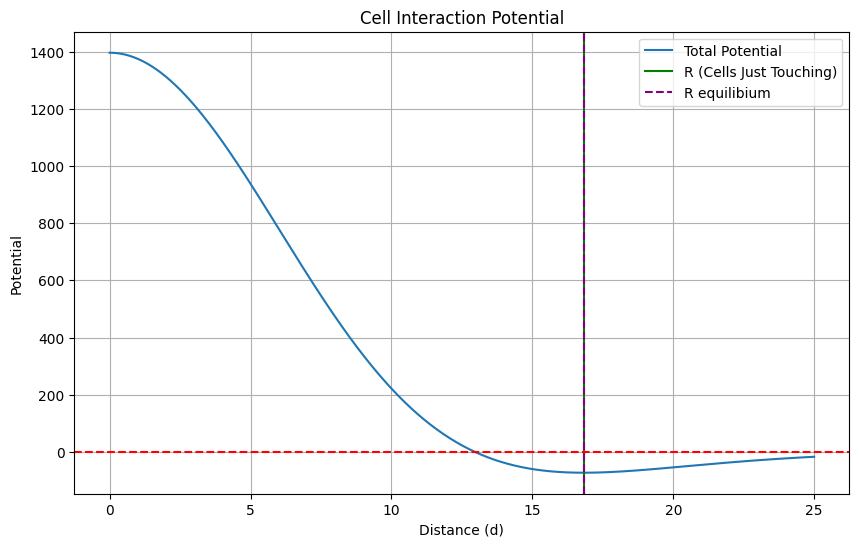

In [42]:
# Distance array
d = np.linspace(0, 25, 1000)

total_potential = []
adhesion_potential = []
repulsion_potential = []
for elem in d:
    potential = simulation_2.cell_interaction_morse_potential(elem)
    total_potential.append(potential)

# Now plot:
plt.figure(figsize=(10, 6))
plt.plot(d, total_potential, label='Total Potential')

# Uncomment these lines if you'd like to also plot the components
# plt.plot(d, repulsion_potential, label='Repulsive Potential')
# plt.plot(d, adhesion_potential, label='Adhesive Potential')

plt.axvline(x=simulation_2.R, color='green', linestyle='-', label='R (Cells Just Touching)')
plt.axvline(x=simulation_2.r_eq, color='purple', linestyle='--', label='R equilibium')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Distance (d)')
plt.ylabel('Potential')
plt.title('Cell Interaction Potential')
plt.legend()
plt.grid(True)
plt.show()

In [43]:
time_step_slider = FloatSlider(value=0.01, min=0.0001, max=0.1, step=0.0001,
                                       description='Time Step (dt):', readout_format='.4f')
initial_velocity_slider = FloatSlider(value=0.0, min=-5.0, max=10.0, step=0.1,
                                              description='Initial Velocity:')
initial_distance_slider = FloatSlider(value=22, min=0.0, max=23, step=0.1,
                                              description='Initial Distance:')

interactive_plot = interactive(simulation_2.simulate_motion,
                                       time_step=time_step_slider,
                                       initial_velocity=initial_velocity_slider,
                                       initial_distance=initial_distance_slider)

display(interactive_plot)

interactive(children=(FloatSlider(value=0.01, description='Time Step (dt):', max=0.1, min=0.0001, readout_form…

# Kelvin-Voigt Model

Equilibrium distance (K-V):  16.826
Spring constant (K-V):  1.0
Dissipation rate (K-V):  0.1


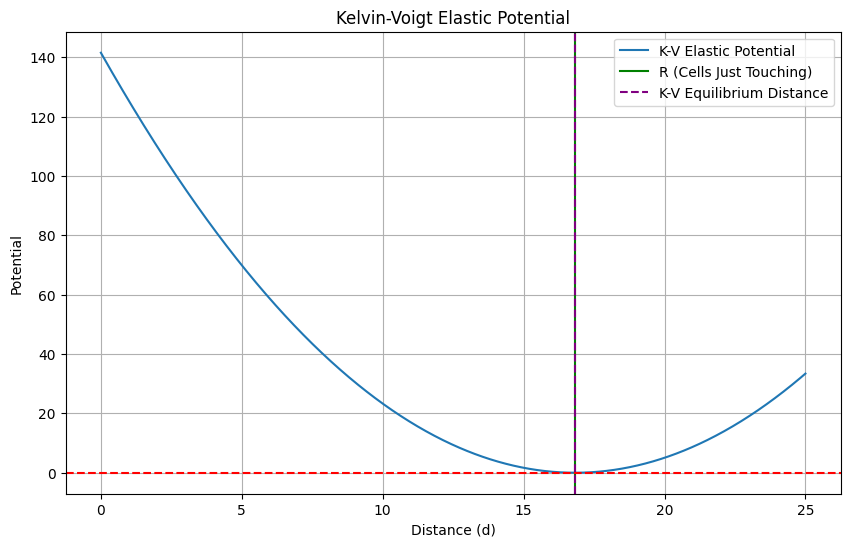

In [44]:
# Initialize the simulation with the K-V model
simulation_kv = CellInteractionSimulation(potential_model="kv")

# Set K-V parameters
simulation_kv.r_default = 8.413
simulation_kv.r1 = simulation_kv.r_default
simulation_kv.r2 = simulation_kv.r_default
# For the Kelvin-Voigt model, define the rest length and the spring/damping constants:
simulation_kv.kv_rest_length = 2 * simulation_kv.r_default   # Equilibrium length, e.g., when cells are just touching or another chosen equilibrium
simulation_kv.kv_spring_constant = 1.0   # Choose a stiffness value
simulation_kv.kv_dissipation_rate = 0.1  # Choose a damping value

print("Equilibrium distance (K-V): ", simulation_kv.kv_rest_length)
print("Spring constant (K-V): ", simulation_kv.kv_spring_constant)
print("Dissipation rate (K-V): ", simulation_kv.kv_dissipation_rate)

# Distance array for plotting
d = np.linspace(0, 25, 1000)
total_potential = []

for elem in d:
    # For K-V, we currently have cell_interaction_kv_potential which returns the elastic potential.
    # The damping is velocity-dependent, so it's not part of this static plot.
    potential = simulation_kv.cell_interaction_kv_potential(elem)
    total_potential.append(potential)

# Now plot the K-V potential curve
plt.figure(figsize=(10, 6))
plt.plot(d, total_potential, label='K-V Elastic Potential')
plt.axvline(x=simulation_kv.R, color='green', linestyle='-', label='R (Cells Just Touching)')
plt.axvline(x=simulation_kv.kv_rest_length, color='purple', linestyle='--', label='K-V Equilibrium Distance')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Distance (d)')
plt.ylabel('Potential')
plt.title('Kelvin-Voigt Elastic Potential')
plt.legend()
plt.grid(True)
plt.show()

In [45]:
time_step_slider = FloatSlider(value=0.01, min=0.0001, max=0.1, step=0.0001,
                                       description='Time Step (dt):', readout_format='.4f')
initial_velocity_slider = FloatSlider(value=0.0, min=-5.0, max=10.0, step=0.1,
                                              description='Initial Velocity:')
initial_distance_slider = FloatSlider(value=22, min=0.0, max=23, step=0.1,
                                              description='Initial Distance:')

interactive_plot = interactive(simulation_kv.simulate_motion,
                                       time_step=time_step_slider,
                                       initial_velocity=initial_velocity_slider,
                                       initial_distance=initial_distance_slider)

Using kv model
F_elastic:  18.174
Using kv model
F_elastic:  18.168547800000006
Using kv model
F_elastic:  18.159451531259997
Using kv model
F_elastic:  18.146706089303144
Using kv model
F_elastic:  18.130307089788708
Using kv model
F_elastic:  18.110250870757234
Using kv model
F_elastic:  18.086534494735453
Using kv model
F_elastic:  18.059155750700278
Using kv model
F_elastic:  18.028113155901302
Using kv model
F_elastic:  17.99340595754102
Using kv model
F_elastic:  17.95503413431235
Using kv model
F_elastic:  17.912998397792684
Using kv model
F_elastic:  17.86730019369407
Using kv model
F_elastic:  17.81794170296893
Using kv model
F_elastic:  17.76492584277083
Using kv model
F_elastic:  17.708256267269782
Using kv model
F_elastic:  17.64793736832184
Using kv model
F_elastic:  17.583974275992226
Using kv model
F_elastic:  17.516372858931994
Using kv model
F_elastic:  17.445139724607557
Using kv model
F_elastic:  17.370282219382986
Using kv model
F_elastic:  17.29180842845461
Using k

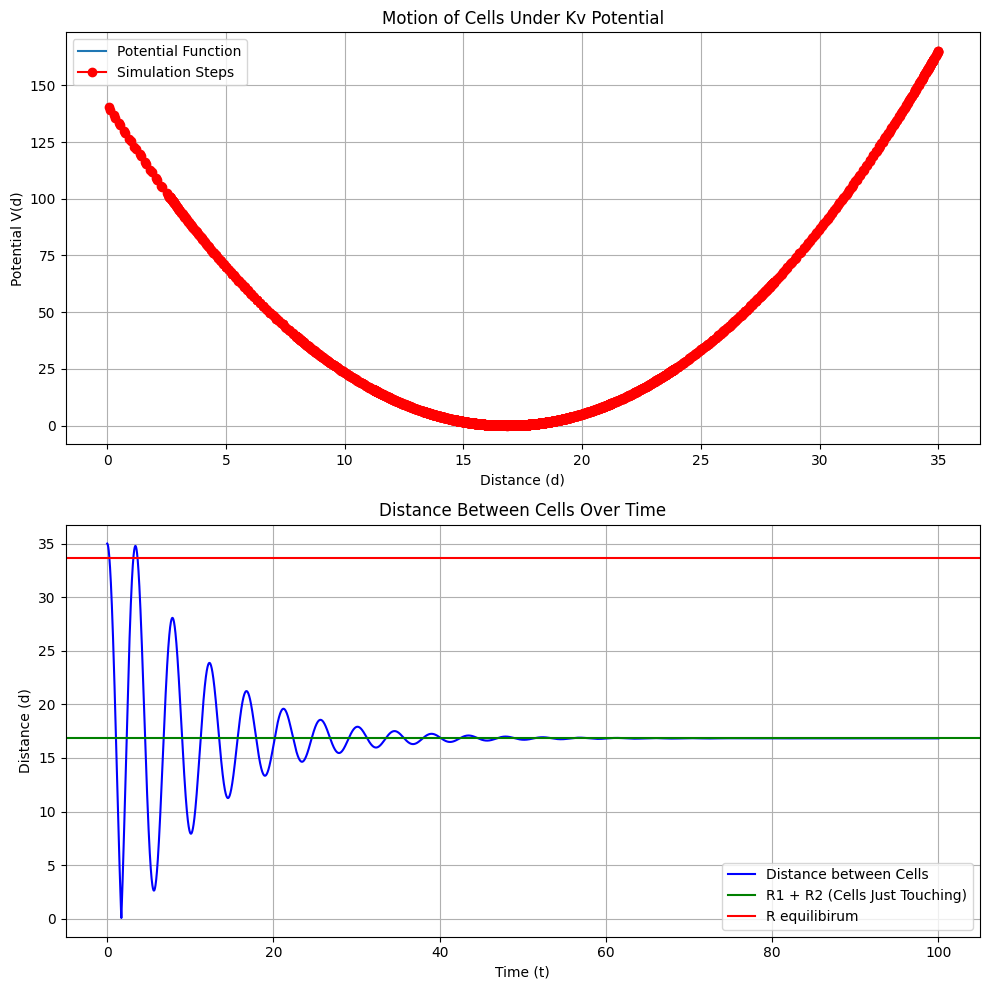

In [46]:
simulation_kv.simulate_motion(0.01, 0.0, 35)